In [1]:
import glob
import re
import numpy as np
import xarray as xr
import pandas as pd
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.dates as mdates
from matplotlib.lines import Line2D

In [2]:
# Fixed base directory
base_dir = "/home/jovyan/SAMBBA_data/dap.ceda.ac.uk/badc/faam/data/2012"

# List of target subdirectories
dirs = [
    "b732-sep-15", "b733-sep-16", 
    "b734-sep-18", "b735-sep-19", "b736-sep-19", "b737-sep-20", "b738-sep-22", 
    "b739-sep-23", "b740-sep-25", "b741-sep-26", "b742-sep-27", "b743-sep-27", 
    "b744-sep-28", "b745-sep-28", "b746-sep-29", "b747-oct-01", "b748-oct-02", 
    "b749-oct-03", "b750-oct-03"
]

In [3]:
# Initialize a list to store file paths
file_paths = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    file_paths.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths)

In [4]:
# List to store filtered file paths
filtered_files = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/core_processed/core_faam*r1*.nc"
    all_files = sorted(glob.glob(path))  # Get all r1 files
    
    # Print files found for debugging
    #print(f"Files found in {path}:")
    #print(all_files)
    
    # Filter out files that contain "_1hz"
    for file in all_files:
        if "_1hz" not in file:  # Exclude _1hz files
            filtered_files.append(file)

# Print or use the collected file paths
#print("\nFiltered files:")
#print(filtered_files)


In [5]:
# Initialize a list to store file paths
file_paths_dry_neph = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/mo-non-core/metoffice*neph1*.nc"
    file_paths_dry_neph.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_dry_neph)

In [6]:
# Initialize a list to store file paths
file_paths_flight_sum = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/flight-sum*.txt"
    file_paths_flight_sum.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_flight_sum)

In [7]:
# Initialize a list to store file paths
file_paths_sp2 = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-sp2*.na"
    file_paths_sp2.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_sp2)

In [8]:
# Initialize a list to store file paths
file_paths_ams = []

# Iterate over each directory and collect .nc files from 'core_processed'
for d in dirs:
    path = f"{base_dir}/{d}/non-core/man-ams*.na"
    file_paths_ams.extend(sorted(glob.glob(path)))

# Print or use the collected file paths
#print(file_paths_ams)

In [9]:
# Function to extract flight number (e.g., "b734") from a file path
def extract_flight_number(file_path):
    match = re.search(r'b\d{3}', file_path)
    return match.group(0) if match else None  # Returns None if no match

# Get flight numbers for each dataset
flights_nc = {extract_flight_number(f) for f in filtered_files}
flights_ams = {extract_flight_number(f) for f in file_paths_ams}
flights_sp2 = {extract_flight_number(f) for f in file_paths_sp2}
flights_neph = {extract_flight_number(f) for f in file_paths_dry_neph}
flights_sum = {extract_flight_number(f) for f in file_paths_flight_sum}

# Find flights that are in all three datasets
common_flights = flights_nc & flights_ams & flights_sp2 & flights_neph & flights_sum # Set intersection

# Filter the file lists to include only matching flights
filtered_nc = [f for f in filtered_files if extract_flight_number(f) in common_flights]
filtered_ams = [f for f in file_paths_ams if extract_flight_number(f) in common_flights]
filtered_sp2 = [f for f in file_paths_sp2 if extract_flight_number(f) in common_flights]
filtered_neph = [f for f in file_paths_dry_neph if extract_flight_number(f) in common_flights]
filtered_sum = [f for f in file_paths_flight_sum if extract_flight_number(f) in common_flights]

# Print the results
print(f"Common flights: {sorted(common_flights)}")
print(f"Filtered NC files: {len(filtered_nc)}")
print(f"Filtered AMS files: {len(filtered_ams)}")
print(f"Filtered SP2 files: {len(filtered_sp2)}")
print(f"Filtered Neph files: {len(filtered_sp2)}")
print(f"Filtered Flight sum files: {len(filtered_sum)}")

Common flights: ['b734', 'b737', 'b739', 'b740', 'b741', 'b742', 'b743', 'b744', 'b745', 'b746', 'b747', 'b748', 'b749', 'b750']
Filtered NC files: 14
Filtered AMS files: 14
Filtered SP2 files: 14
Filtered Neph files: 14
Filtered Flight sum files: 14


In [10]:
filtered_nc[0]

# Extract the date (format: yyyymmdd)
match = re.search(r'(\d{8})', filtered_nc[0])

# Get the matched date or None if not found
flight_date = match.group(1) if match else None

print(flight_date)  # Output: 20120914

20120918


In [11]:
ds_C0 = xr.open_dataset(filtered_nc[0])
ds_C0

<xarray.Dataset> Size: 281MB
Dimensions:         (data_point: 25820, sps32: 32, sps04: 4, sps01: 1,
                     sps02: 2, sps64: 64)
Dimensions without coordinates: data_point, sps32, sps04, sps01, sps02, sps64
Data variables: (12/141)
    Time            (data_point) datetime64[ns] 207kB ...
    IAS_RVSM        (data_point, sps32) float32 3MB ...
    IAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAS_RVSM        (data_point, sps32) float32 3MB ...
    TAS_RVSM_FLAG   (data_point, sps32) float32 3MB ...
    TAT_DI_R        (data_point, sps32) float32 3MB ...
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 103kB ...
    TDEW_C_U_FLAG   (data_point, sps01) float32 103kB ...
    U_NOTURB        (data_point, sps01) float32 103kB ...
    U_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
    V_NOTURB        (data_point, sps01) float32 103kB ...
    V_NOTURB_FLAG   (data_point, sps01) float32 103kB ...
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

In [12]:
ds_CO_resampled = ds_C0.resample(Time="1min").mean()

In [13]:
valid_CO = ds_CO_resampled["CO_AERO_FLAG"] == 0
filtered_CO = ds_CO_resampled.where(valid_CO, drop=True)

In [14]:
filtered_CO

<xarray.Dataset> Size: 2MB
Dimensions:         (data_point: 228, sps32: 32, sps01: 1, sps04: 4, sps02: 2,
                     sps64: 64)
Coordinates:
  * data_point      (data_point) datetime64[ns] 2kB 2012-09-18T10:26:00 ... 2...
Dimensions without coordinates: sps32, sps01, sps04, sps02, sps64
Data variables: (12/140)
    IAS_RVSM        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 67.19
    IAS_RVSM_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    TAS_RVSM        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 70.01
    TAS_RVSM_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    TAT_DI_R        (data_point, sps32, sps01) float32 29kB 0.0 0.0 ... 303.9
    TAT_DI_R_FLAG   (data_point, sps32, sps01) float32 29kB 3.0 3.0 ... 0.0 0.0
    ...              ...
    TDEW_C_U        (data_point, sps01) float32 912B nan nan ... 0.3587 0.3582
    TDEW_C_U_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 0.0 0.0 0.0
    U_NOTURB        (data_point, sps01) float32 912B nan nan nan ... 1.401 2.117
    U_NOTURB_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 2.7 1.15
    V_NOTURB        (data_point, sps01) float32 912B nan nan ... -3.222 -2.975
    V_NOTURB_FLAG   (data_point, sps01) float32 912B 3.0 3.0 3.0 ... 2.7 1.15
Attributes: (12/22)
    conventions:         CF-1.0
    title:               Data from b734 on 18-SEP-12
    institution:         FAAM
    source:              FAAM BAe-146 Aircraft Data
    references:          http://www.faam.ac.uk
    Cal_Input_Files:     Input files:\n/home/tardis/data/fltcons/flight-cst_f...
    ...                  ...
    Tardis_Version:      v004
    Format_Version:      1.00
    comment:             FAAM data core_faam_yyyymmdd_vnnn_rn_cnnn.nc\n where...
    Data_Date:           20130619
    TimeInterval:        08:52:02-16:02:21
    History:             Dataset /home/tardis/data/ncdata/core_faam_20120918_...

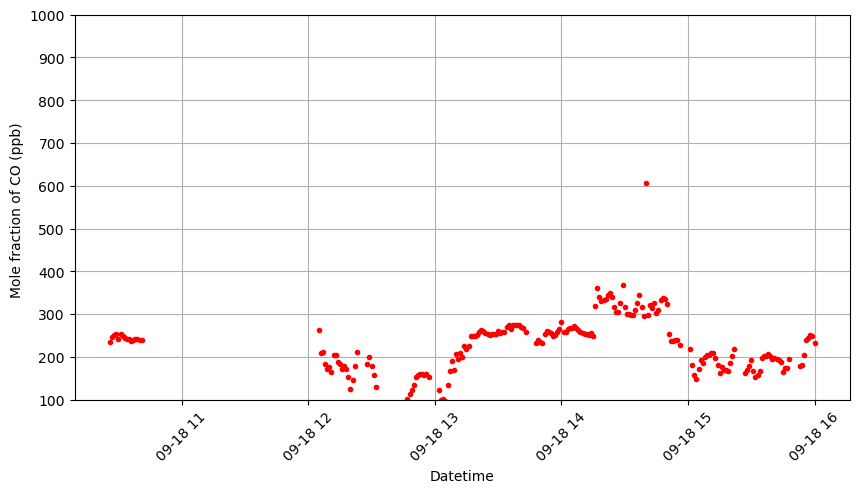

In [15]:
plt.figure(figsize=(10, 5))
plt.plot(filtered_CO['data_point'].squeeze(), filtered_CO['CO_AERO'], color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])
plt.ylim(100,1000)
# Formatting
plt.xlabel("Datetime")
plt.ylabel("Mole fraction of CO (ppb) ")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

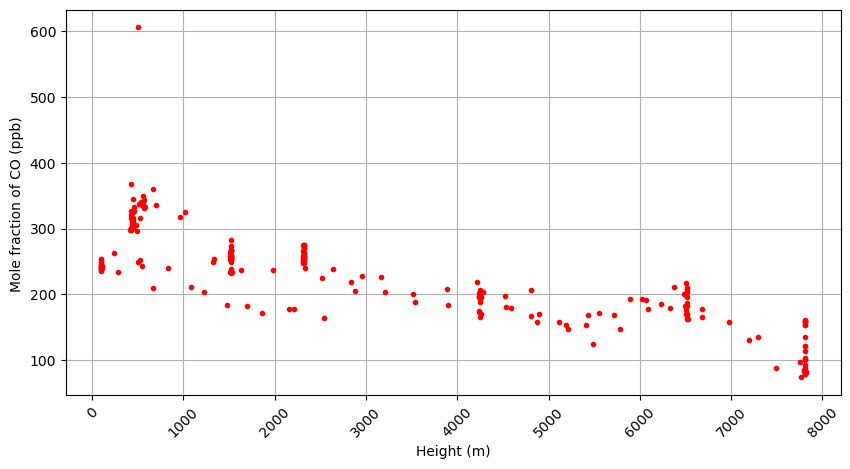

In [16]:
plt.figure(figsize=(10, 5))
plt.plot(filtered_CO['GPS_ALT'], filtered_CO['CO_AERO'], color="r", marker='.',linewidth=0)
#plt.xlim(filtered_ds_psap['Time'][550],filtered_ds_psap['Time'][3000])
#plt.ylim(100,1000)
# Formatting
plt.xlabel("Height (m)")
plt.ylabel("Mole fraction of CO (ppb) ")
#plt.title("Mass absortion efficiency Over Time")
plt.xticks(rotation=45)
plt.grid()

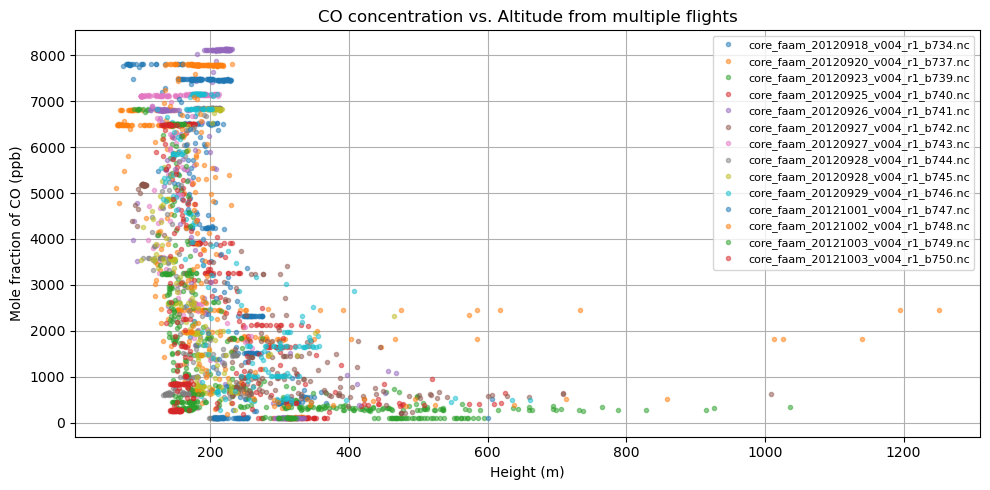

In [18]:

plt.figure(figsize=(10, 5))

# Iterate over all matching flights
for sp2_file, ams_file, nc_file, neph_file in zip(filtered_sp2, filtered_ams, filtered_nc, filtered_neph):
    
    ds_CO = xr.open_dataset(nc_file)  # unpack from zip tuple
    ds_CO_resampled = ds_CO.resample(Time="1min").mean()

    # Apply filter
    valid_CO = ds_CO_resampled["CO_AERO_FLAG"] == 0
    filtered_CO = ds_CO_resampled.where(valid_CO, drop=True)

    # Plot
    plt.plot(
        filtered_CO["CO_AERO"],
        filtered_CO["GPS_ALT"],
        marker=".",
        linewidth=0,
        alpha=0.5,
        label=nc_file.split("/")[-1]  # Optional: show filename as label
    )

# Formatting
plt.xlabel("Height (m)")
plt.ylabel("Mole fraction of CO (ppb)")
plt.grid()
plt.legend(loc="best", fontsize=8)
plt.title("CO concentration vs. Altitude from multiple flights")
plt.tight_layout()
plt.show()
    